# Lab 2: Energy-Tracking Projectile

Name: 
Date: 
Lab: PHYS 311 Module 2

This notebook adds energy tracking to the Lab 1 projectile simulator, compares the standard Euler and Euler-Cromer integrators, and runs a convergence study on the energy drift.

**AI use disclaimer:** AI (Claude) was used in preparing this notebook for coding assistance, tidying up code, and improving code flow/organization. This is not to say that there was no human work done in this code; all lines included input and assistance from myself and many iterations and human attempts are consolidated into the notebook seen below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Part A: Add Energy Tracking

We start from the gravity-only 2D projectile from Lab 1 and add kinetic energy, potential energy, and total mechanical energy at every time step. Since gravity is a conservative force, total energy should stay constant if the integrator is doing its job.

In [2]:
def simulate_projectile_energy(v0, theta_deg, dt, g=9.81, m=1.0):
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    t = 0.0

    KE0 = 0.5 * m * (vx**2 + vy**2)
    PE0 = m * g * y

    t_list, x_list, y_list = [t], [x], [y]
    vx_list, vy_list = [vx], [vy]
    KE_list, PE_list, E_list = [KE0], [PE0], [KE0 + PE0]

    while y >= 0:
        vx_old, vy_old = vx, vy
        vy = vy - g * dt
        x = x + vx_old * dt
        y = y + vy_old * dt
        t = t + dt

        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E = KE + PE

        t_list.append(t)
        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)
        KE_list.append(KE)
        PE_list.append(PE)
        E_list.append(E)

    return (np.array(t_list), np.array(x_list), np.array(y_list),
            np.array(vx_list), np.array(vy_list),
            np.array(KE_list), np.array(PE_list), np.array(E_list))

Launch from the origin at 30 m/s and 50 degrees, m = 1.0 kg, dt = 0.01 s.

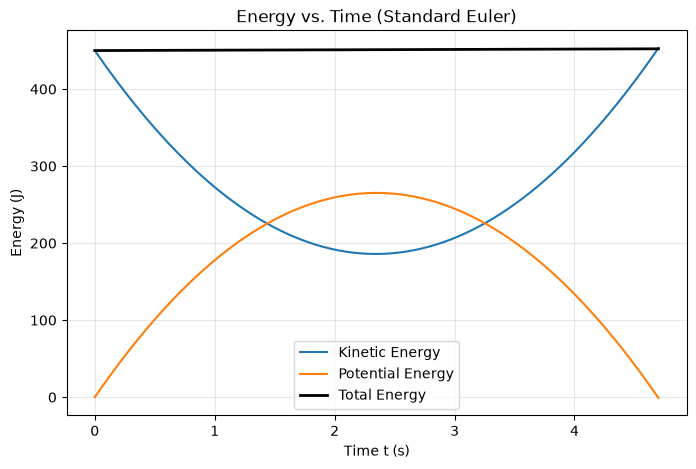

In [3]:
v0 = 30.0
theta_deg = 50.0
dt = 0.01
g = 9.81
m = 1.0

t_a, x_a, y_a, vx_a, vy_a, KE_a, PE_a, E_a = simulate_projectile_energy(v0, theta_deg, dt, g, m)

plt.figure(figsize=(8, 5))
plt.plot(t_a, KE_a, label='Kinetic Energy')
plt.plot(t_a, PE_a, label='Potential Energy')
plt.plot(t_a, E_a, label='Total Energy', linewidth=2, color='black')
plt.xlabel('Time t (s)')
plt.ylabel('Energy (J)')
plt.title('Energy vs. Time (Standard Euler)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

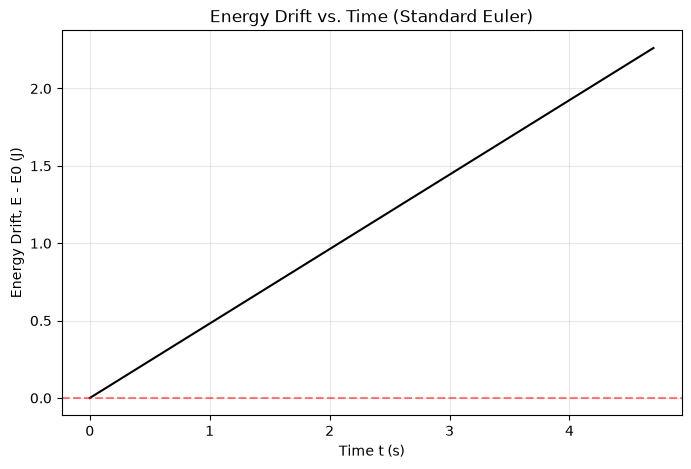

In [4]:
E0 = E_a[0]
E_drift = E_a - E0

plt.figure(figsize=(8, 5))
plt.plot(t_a, E_drift, color='black')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Time t (s)')
plt.ylabel('Energy Drift, E - E0 (J)')
plt.title('Energy Drift vs. Time (Standard Euler)')
plt.grid(alpha=0.3)
plt.show()

In [5]:
max_drift = np.max(np.abs(E_drift))
max_drift_pct = max_drift / abs(E0) * 100

print(f"Initial energy: {E0:.3f} J")
print(f"Max absolute energy drift: {max_drift:.3f} J")
print(f"Max energy drift as percent of initial energy: {max_drift_pct:.3f} %")

Initial energy: 450.000 J
Max absolute energy drift: 2.262 J
Max energy drift as percent of initial energy: 0.503 %


**Interpretation:** The total energy grows steadily over the flight rather than oscillating, since standard Euler uses the old velocity to move the ball forward each step, which slightly overshoots the true height at every single step and never corrects itself. The drift is small mainly because the flight is short and dt is small, but the the error keeps accumulating rather than cancelling out.

## Part B: Euler vs. Euler-Cromer

Euler-Cromer differs from standard Euler by one reordering: update the velocity first, then use the new velocity to move the position. We write one function that can run either method so we are not keeping two nearly identical loops around.

In [6]:
def simulate(method, dt, v0=30.0, angle_deg=50.0, g=9.81, m=1.0):
    theta = np.radians(angle_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    t = 0.0

    KE0 = 0.5 * m * (vx**2 + vy**2)
    PE0 = m * g * y

    t_list, x_list, y_list = [t], [x], [y]
    vx_list, vy_list = [vx], [vy]
    KE_list, PE_list, E_list = [KE0], [PE0], [KE0 + PE0]

    while y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            x = x + vx * dt
            y = y + vy * dt
            vx = vx + ax * dt
            vy = vy + ay * dt
        elif method == 'euler-cromer':
            vx = vx + ax * dt
            vy = vy + ay * dt
            x = x + vx * dt
            y = y + vy * dt

        t = t + dt
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E = KE + PE

        t_list.append(t)
        x_list.append(x)
        y_list.append(y)
        vx_list.append(vx)
        vy_list.append(vy)
        KE_list.append(KE)
        PE_list.append(PE)
        E_list.append(E)

    return (np.array(t_list), np.array(x_list), np.array(y_list),
            np.array(vx_list), np.array(vy_list),
            np.array(KE_list), np.array(PE_list), np.array(E_list))

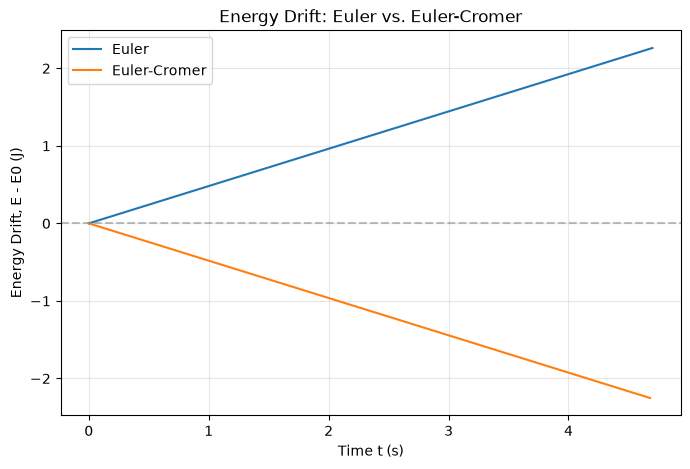

In [7]:
dt = 0.01

t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_e = simulate('euler', dt)
t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_ec = simulate('euler-cromer', dt)

plt.figure(figsize=(8, 5))
plt.plot(t_e, E_e - E_e[0], label='Euler')
plt.plot(t_ec, E_ec - E_ec[0], label='Euler-Cromer')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Time t (s)')
plt.ylabel('Energy Drift, E - E0 (J)')
plt.title('Energy Drift: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

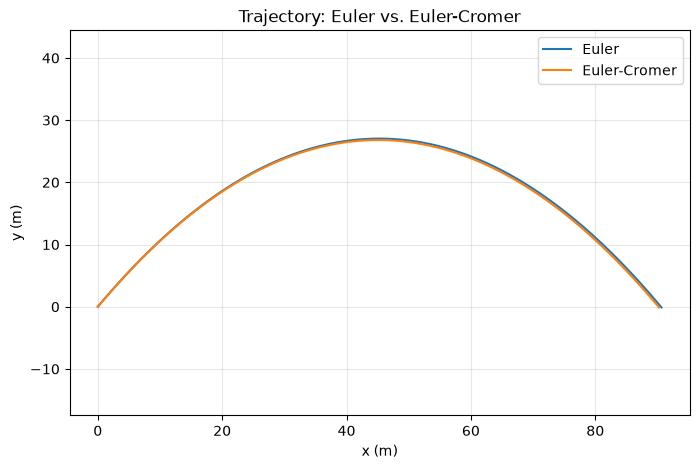

Range, Euler: 90.633 m
Range, Euler-Cromer: 90.247 m
Difference in range: 0.386 m


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(x_e, y_e, label='Euler')
plt.plot(x_ec, y_ec, label='Euler-Cromer')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Trajectory: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(alpha=0.3)
plt.axis('equal')
plt.show()

range_e = x_e[-1]
range_ec = x_ec[-1]
print(f"Range, Euler: {range_e:.3f} m")
print(f"Range, Euler-Cromer: {range_ec:.3f} m")
print(f"Difference in range: {abs(range_e - range_ec):.3f} m")

**Explanation:** Gravity does not depend on position here, so the acceleration is the same constant value in both methods, and the velocity sequence ends up the same for Euler and Euler-Cromer. The only thing that changes is which velocity value gets used to move the position forward that step, either the old one or the new one. Using the old velocity makes standard Euler consistently overshoot the true height, so it slowly gains energy, while using the new velocity makes Euler-Cromer undershoot the true height, so it slowly loses energy. That is why the two drift curves above come out to almost the same size but opposite sign. The small range difference between the two comes from that same position offset changing when each method's while loop decides y has dropped below zero.

## Part C: Convergence Study

Now we check how the energy drift scales with step size for both methods, using the same launch conditions as Parts A and B.

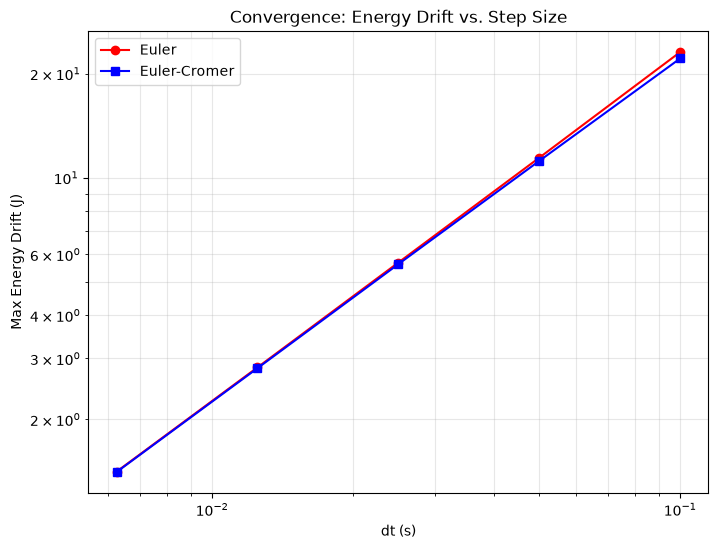

In [9]:
dt_values = [0.1, 0.05, 0.025, 0.0125, 0.00625]
max_drift_euler = []
max_drift_ec = []

for dt_test in dt_values:
    _, _, _, _, _, _, _, E_test_e = simulate('euler', dt_test)
    _, _, _, _, _, _, _, E_test_ec = simulate('euler-cromer', dt_test)
    max_drift_euler.append(np.max(np.abs(E_test_e - E_test_e[0])))
    max_drift_ec.append(np.max(np.abs(E_test_ec - E_test_ec[0])))

max_drift_euler = np.array(max_drift_euler)
max_drift_ec = np.array(max_drift_ec)

plt.figure(figsize=(8, 6))
plt.loglog(dt_values, max_drift_euler, 'ro-', label='Euler')
plt.loglog(dt_values, max_drift_ec, 'bs-', label='Euler-Cromer')
plt.xlabel('dt (s)')
plt.ylabel('Max Energy Drift (J)')
plt.title('Convergence: Energy Drift vs. Step Size')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.show()

In [10]:
slope_euler = np.polyfit(np.log(dt_values), np.log(max_drift_euler), 1)[0]
slope_ec = np.polyfit(np.log(dt_values), np.log(max_drift_ec), 1)[0]

print(f"Euler slope (order p): {slope_euler:.3f}")
print(f"Euler-Cromer slope (order p): {slope_ec:.3f}")

target_pct = 0.01
E0_check = 0.5 * m * v0**2
target_drift = target_pct / 100 * E0_check

C_euler = max_drift_euler[-1] / dt_values[-1]**slope_euler
dt_needed = (target_drift / C_euler) ** (1 / slope_euler)
print(f"Estimated dt needed for 0.01% drift (Euler): {dt_needed:.6f} s")

Euler slope (order p): 1.008
Euler-Cromer slope (order p): 0.994
Estimated dt needed for 0.01% drift (Euler): 0.000205 s


**Analysis:**

The fitted slope for standard Euler comes out close to 1, matching the first-order behavior the lesson predicted for Euler.

Euler-Cromer's curve is not smaller at any of the step sizes tested. It sits right on top of the standard Euler curve. The two methods make position errors of the same size and only the sign differs, so squaring/summing into an energy error gives the same magnitude either way. Euler-Cromer's usual advantage shows up for oscillatory systems like springs and orbits.

For 0.01% energy conservation, the data says it does not matter which of the two methods is used here, since they scale the same way, only the step size matters. Extrapolating the fitted line from the convergence data gives a rough estimate of the dt that would be needed, which is much smaller than anything used in this lab.

## Bonus: Drag and Physical Energy Loss

With drag, mechanical energy should decrease. We add drag to the Euler-Cromer simulation and check that the energy lost matches the work done against drag.

In [11]:
def simulate_drag_ec(v0, theta_deg, dt, g, m, b_over_m):
    theta = np.radians(theta_deg)
    x, y = 0.0, 0.0
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    t = 0.0

    KE0 = 0.5 * m * (vx**2 + vy**2)
    PE0 = m * g * y

    t_list, y_list = [t], [y]
    KE_list, PE_list, E_list = [KE0], [PE0], [KE0 + PE0]
    W_drag = 0.0

    while y >= 0:
        speed = np.sqrt(vx**2 + vy**2)
        Fdrag_x = -m * b_over_m * speed * vx
        Fdrag_y = -m * b_over_m * speed * vy
        W_drag += (Fdrag_x * vx + Fdrag_y * vy) * dt

        ax = Fdrag_x / m
        ay = -g + Fdrag_y / m
        vx = vx + ax * dt
        vy = vy + ay * dt
        x = x + vx * dt
        y = y + vy * dt
        t = t + dt

        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E = KE + PE

        t_list.append(t)
        y_list.append(y)
        KE_list.append(KE)
        PE_list.append(PE)
        E_list.append(E)

    return (np.array(t_list), np.array(y_list),
            np.array(KE_list), np.array(PE_list), np.array(E_list), W_drag)

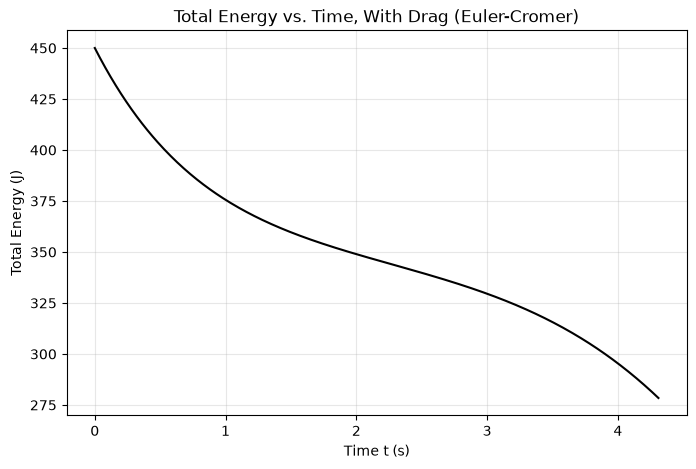

In [12]:
b_over_m = 0.0046

t_d, y_d, KE_d, PE_d, E_d, W_drag = simulate_drag_ec(v0, theta_deg, dt, g, m, b_over_m)

plt.figure(figsize=(8, 5))
plt.plot(t_d, E_d, color='black')
plt.xlabel('Time t (s)')
plt.ylabel('Total Energy (J)')
plt.title('Total Energy vs. Time, With Drag (Euler-Cromer)')
plt.grid(alpha=0.3)
plt.show()

In [13]:
E_lost = E_d[0] - E_d[-1]

print(f"Energy lost over the flight: {E_lost:.3f} J")
print(f"Work done against drag (magnitude): {abs(W_drag):.3f} J")
print(f"Difference: {abs(E_lost - abs(W_drag)):.3f} J")
print(f"Percent difference: {abs(E_lost - abs(W_drag)) / E_lost * 100:.2f} %")

Energy lost over the flight: 171.571 J
Work done against drag (magnitude): 169.583 J
Difference: 1.988 J
Percent difference: 1.16 %


Total energy now drops monotonically instead of drifting upward, which is what we expect once a non-conservative force is in the picture. The energy lost over the flight matches the work done against drag to within a small percent, with the leftover difference coming from the same kind of Euler-Cromer step-size error seen in Parts A through C rather than from a mistake in the drag force itself.